# Applied Math 10: Computing for Science and Engineering

## Section 07 : Numerical Integration

**Fall 2020**<br/>
<br>



### Learning Goals 

This Section focuses on calculating integrals using the rectangular approximation, the trapezoidal approximation, and the Simpson's 1/3 rule. You will also use the `quad` routine from the `scipy` library. By the end of this Section, you will be able to:
- use the functions coded in the Lab to numerically calculate integrals;
- explore the relative accuracy of the aforementioned numerical integration methods;
- compute simple "improper" integrals.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi
import time

##### Reference on numpy functions

https://docs.scipy.org/doc/numpy-1.13.0/reference/routines.math.html

## Review: functions for the rectangular, trapezoidal, and Simpson's methods. 

In [2]:
# Convert the basic integration approximations into functions.
# Start with the rectangular approximation.

def rectnv(f, xmin, xmax):
    ''' The input is: discretized values of the function, f;
                   lower and upper limits of integration, xmin and xmax
        The output is: the integral of the function f between the lower and upper limits xmin and xmax
    '''
    
    #Find Nx from the discretized function f
    
    Nx=len(f)-1
    
    #Find Dx 
    
    Dx = (xmax - xmin) / Nx
    
    #Write the expression for integral
    
    Ints = Dx * np.sum(f) - Dx * f[Nx]
    
    return Ints

In [3]:
# Trapezoidal approximation

def trapznv(f, xmin, xmax):
    
    ''' The input is: discretized values of the function, f;
                   limits of integration, xmin and xmax
        The output is: the integral of the function f between the limits of integration xmin and xmax
    '''
    
    # Find Nx (number of intervals)
    
    Nx=len(f)-1
    
    #Find Dx
    
    Dx = (xmax - xmin) / Nx
    
    #Find the integral
    
    Ints=Dx*np.sum(f)-0.5*Dx*f[0]-0.5*Dx*f[Nx]
    
    return Ints

In [4]:
def simpnv(f, xmin, xmax):
    
    ''' The input is: discretized values of the function, f;
                   limits of integration, xmin and xmax
        The output is: the integral of the function f between the limits of integration xmin and xmax
    '''
    
    # Find Nx and Dx
    
    Nx=len(f)-1
    Dx = (xmax - xmin) / Nx
    
    sum1 = 0.0
    sum2 = 0.0
    
    #Compute the sums for even and odd terms
    
    for n in range(1, Nx):
        if n % 2 == 1:    # check n is odd and compute sum1
            sum1 += f[n]  # This is the same as sum1 = sum1 + f[n]
        if n % 2 == 0:    # check n is even and compute sum2 
            sum2 += f[n]  # 
    
    Ints = (1.0 / 3.0) * Dx * (f[0] + 4.0 * sum1 + 2.0 * sum2 + f[Nx])
    
    return Ints

___________________________________________________________________________________________________________________________

## Problem 1

Use the methods studied in order to compute the following integral for Nx=64 up to $2^{16}$: 

$$\int_{0}^{5\pi} \frac{\sin{10x}}{\sqrt{x^2+1}} dx$$

In [5]:
# Function definition
def fx(x):
# Note: this function is defined for all values of x
    return np.sin(10*x)/np.sqrt(1.0+x**2)

In [6]:
Iexact1 = 0.0947736

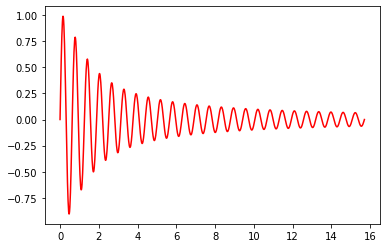

In [7]:
#Define the limits of integration and discretize
#the independent variable and the function.
# Plot the function to get a feel for what to expect.

xmin = 0
xmax = 5*np.pi
Nx = 1024
x = np.linspace(xmin,xmax,Nx+1)
f = np.zeros(Nx+1)
for n in range(Nx+1):
    f[n] = fx(x[n])
    
plt.plot(x, f, 'r')
plt.show()

### Accuracy of the three numerical approximations

In [8]:
# calculate the integral 

Ms=11
for m in range(Ms):
    Nx=2**(m+6)
    Dx=(xmax-xmin)/Nx
    x=np.linspace(xmin,xmax,Nx+1)
    f=np.zeros(Nx+1)
    for n in range(Nx+1):
        f[n]=fx(x[n])
    Intrect=rectnv(f, xmin, xmax)
    Inttrap=trapznv(f, xmin, xmax)
    Intsimp=simpnv(f, xmin, xmax)
    
    print('%8i'%Nx,'%12.7f'%Iexact1,'%12.7f'%Intrect,'%12.7f'%Inttrap,'%12.7f'%Intsimp)  

      64    0.0947736    0.0419814    0.0419814    0.1603936
     128    0.0947736    0.0827044    0.0827044    0.0962787
     256    0.0947736    0.0918163    0.0918163    0.0948536
     512    0.0947736    0.0940379    0.0940379    0.0947784
    1024    0.0947736    0.0945899    0.0945899    0.0947739
    2048    0.0947736    0.0947277    0.0947277    0.0947736
    4096    0.0947736    0.0947621    0.0947621    0.0947736
    8192    0.0947736    0.0947707    0.0947707    0.0947736
   16384    0.0947736    0.0947729    0.0947729    0.0947736
   32768    0.0947736    0.0947734    0.0947734    0.0947736
   65536    0.0947736    0.0947736    0.0947736    0.0947736


### Compare with `SciPy` numerical integration functions

`SciPy` is a powerful python library. To compute numerical integration, we mainly use the `integrate` module. Its numerical routines can be categorized into two types: (a) routines that take the integrand as a python function and (b) routines that take arrays with samples of the integrand at given points. The functions of the first type use Gaussian quadrature (quad, quadrature, fixed_quad), while functions of the second type use Newton-Cotes methods (trapz, simps, and romb).

We import Scipy as:
`import scipy.integrate as spi`

In the following problem, you will use the `spi.trapz` and the `spi.simps` routines to compute numerically the integral, and compare this result to the results obtained by the rectangular, trapezoidal method and Simpson's '1/3'-rule method. 

In [9]:
Ms=11
for m in range(Ms):
    Nx=2**(m+6)
    Dx=(xmax-xmin)/Nx
    x=np.linspace(xmin,xmax,Nx+1)
    f=np.zeros(Nx+1)
    for n in range(Nx+1):
        f[n]=fx(x[n])
    Intrect=rectnv(f, xmin, xmax)
    Inttrap=trapznv(f, xmin, xmax)
    Intsimp=simpnv(f, xmin, xmax)
    
    Ispitrapz = spi.trapz(f,x)
    Ispisimps = spi.simps(f,x)
    
    print('%8i'%Nx,'%12.7f'%Iexact1,'%12.7f'%Intrect,'%12.7f'%Inttrap,'%12.7f'%Intsimp, '%12.7f'%Ispitrapz, '%12.7f'%Ispisimps)  

      64    0.0947736    0.0419814    0.0419814    0.1603936    0.0419814    0.1603936
     128    0.0947736    0.0827044    0.0827044    0.0962787    0.0827044    0.0962787
     256    0.0947736    0.0918163    0.0918163    0.0948536    0.0918163    0.0948536
     512    0.0947736    0.0940379    0.0940379    0.0947784    0.0940379    0.0947784
    1024    0.0947736    0.0945899    0.0945899    0.0947739    0.0945899    0.0947739
    2048    0.0947736    0.0947277    0.0947277    0.0947736    0.0947277    0.0947736
    4096    0.0947736    0.0947621    0.0947621    0.0947736    0.0947621    0.0947736
    8192    0.0947736    0.0947707    0.0947707    0.0947736    0.0947707    0.0947736
   16384    0.0947736    0.0947729    0.0947729    0.0947736    0.0947729    0.0947736
   32768    0.0947736    0.0947734    0.0947734    0.0947736    0.0947734    0.0947736
   65536    0.0947736    0.0947736    0.0947736    0.0947736    0.0947736    0.0947736


### Using one more `SciPy` routine: `integrate.quad`

In [10]:
#from scipy import integrate
from scipy import integrate

val2, err = integrate.quad(fx,xmin,xmax)
print('Value obtained from integrate.quad: ', val2)

Value obtained from integrate.quad:  0.09477361406488818


__________________________________________________________________________________________________________________________

### Improper integrals -- what happens if the integrand blows up in the domain of integration?

## Problem 2

#### Improper Integral -  Integrand goes to infinity within the limits of integration

Calculate the following integral:

$$\int_{0}^{2} \frac{1}{1-x^2} dx$$


In [11]:
def fx2(x):
     return 1/(1-x*x)

C:\Users\george\anaconda3\lib\site-packages\ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in double_scalars
  


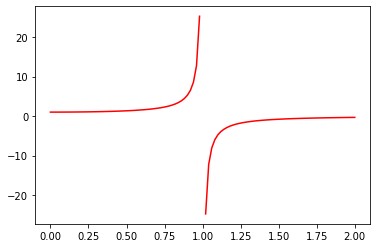

In [12]:
xmin = 0
xmax = 2
Nx = 100
x = np.linspace(xmin, xmax, Nx + 1)
f = np.zeros(Nx + 1)

for n in range(Nx + 1):
    f[n] = fx2(x[n])

plt.plot(x, f, 'r')
plt.show()

Clearly, any attempt to evaluate the integral numerically as it is fails. We will try a different approach.

#### Our approach: 
We will attempt to calculate the integral as:

$$Lim_{\epsilon->0}\left [\int_{0}^{1-\epsilon} \frac{1}{1-x^2} dx+\int_{1+\epsilon}^{2} \frac{1}{1-x^2} dx \right ]$$

In general, there is no guarantee such a limit exists. 


- choose a small number (epsilon) and compute the integral from 0 to 1-epsilon and call it Int_1
- compute the integral from 1+epsilon to 2 and call it Int_2
- estimate the final integral by adding Int_1 and Int_2 
- you will need to repeat this with smaller epsilon to get an accurate estimate

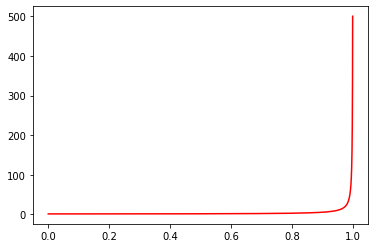

In [22]:
#epsilon values to try: 0.1, 0.01, 0.001, 0.0001, 0.00001
epsilon=0.001
#Nx values to try: 100, 1000, 10000, 100000, 1000000
Nx=10000

xmin = 0
xmax = 1.0-epsilon

x = np.linspace(xmin, xmax, Nx + 1)
f = np.zeros(Nx + 1)

for n in range(Nx + 1):
    f[n] = fx2(x[n])

plt.plot(x, f, 'r')
plt.show()

In [23]:
Int_1=simpnv(f, xmin, xmax)
print(Int_1)

3.80020278943606


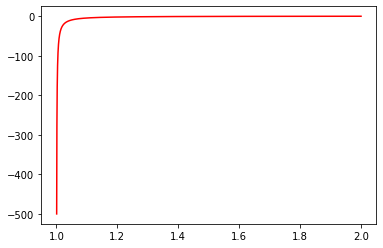

In [24]:
xmin=1.0+epsilon
xmax=2.0

x = np.linspace(xmin, xmax, Nx + 1)
f = np.zeros(Nx + 1)

for n in range(Nx + 1):
    f[n] = fx2(x[n])

plt.plot(x, f, 'r')
plt.show()

In [25]:
Int_2=simpnv(f, xmin, xmax)
print(Int_2)

-3.251396645143712


In [26]:
Int_1+Int_2

0.5488061442923482

#### Numerically calculate the integral by means of `integrate.quad`

In [27]:
a = 0
b = 2

val3, err = integrate.quad(fx2, a, b, points=[1])
print('Value obtained from integrate.quad: ', val3)

Value obtained from integrate.quad:  0.5493061443327966


C:\Users\george\anaconda3\lib\site-packages\ipykernel_launcher.py:4: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  after removing the cwd from sys.path.


___________________________________________________________________________________________________________________________

### Convolution

The convolution of two functions is an important concept in getting information from a signal (for example, extracting frequency information from a time-domain signal). You can think of convolution as a time series of the "signal", $f(t)$, weighted by a "sampling pulse", $g(t)$, that slides along the signal, thus obtaining a result that shows what features these two functions have in common. 

You can find informative animations and an introductory presentation in Wikipedia (https://en.wikipedia.org/wiki/Convolution). Convolution has applications that include probability, statistics, computer vision, natural language processing, image and signal processing, engineering, and differential equations.


Consider the functions $f(t)$ and $g(t)$ that represent the signal and the sampling pulse. Their convolution, denoted as $(f∗g)(t)$, is defined by the integral:

$${\displaystyle (f*g)(t)\equiv \ \int _{-\infty }^{\infty }f(\tau )g(t-\tau )\,d\tau }$$

A rectangular pulse is a function which is constant for a time interval $t\in [t_1,t_2]$ and is zero everywhere else.  Typically, a SAMPLING PULSE is also normalized, that is, the integral of $g(t)$ over all values of $t$ is equal to 1.

Problem 4 in HW asks you to calculate and plot the convolution $(f*g)(t)$ where $f(t)$ is the signal, and it is a recatangular pulse, and $g(t)$ is the sampling function, also a rectangular pulse (choose your own parameters to generate the signal and the sampling pulses).

___________________________________________________________________________________________________________________________

## Problem 3

Using the functions we have constructed, evaluate the following integral:
$$\int_{0}^{x_{max}} \cos{(x^8)} \ dx$$

Evaluate the integral for $x_{max} = \pi $.

Try Nx values from 16 up to 1048576.

In [28]:
# Function definition
def fx(x):
# This function is defined for all values of x
    return np.cos(x**8)


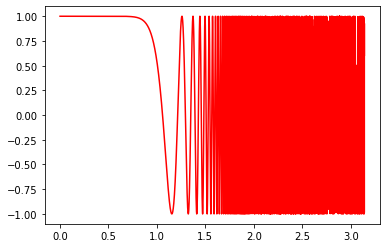

In [29]:
#Define the limits of integration and discretize
#the independent variable and the function.
# Plot the function to get a feel for what to expect.

xmin = 0
#xmax = 3*np.pi/4
xmax = np.pi
Nx = 10000
x = np.linspace(xmin,xmax,Nx+1)
f = np.zeros(Nx+1)
for n in range(Nx+1):
    f[n] = fx(x[n])
    
plt.plot(x, f, 'r')
plt.show()

In [30]:
Iexact1 = 0.9236803

In [32]:
Ms=9
for m in range(Ms):
    Nx=4**(m+2)
    Dx=(xmax-xmin)/Nx
    x=np.linspace(xmin,xmax,Nx+1)
    f=np.zeros(Nx+1)
    for n in range(Nx+1):
        f[n]=fx(x[n])
    Intrect=rectnv(f, xmin, xmax)
    Inttrap=trapznv(f, xmin, xmax)
    Intsimp=simpnv(f, xmin, xmax)
    
    Ispitrapz = spi.trapz(f,x)
    Ispisimps = spi.simps(f,x)
    
    print('%8i'%Nx,'%12.7f'%Iexact1,'%12.7f'%Intrect,'%12.7f'%Inttrap,'%12.7f'%Intsimp, '%12.7f'%Ispitrapz, '%12.7f'%Ispisimps)  

      16    0.9236803    1.8409718    1.8021794    1.8150615    1.8021794    1.8150615
      64    0.9236803    0.9388267    0.9291285    0.8391871    0.9291285    0.8391871
     256    0.9236803    1.0788516    1.0764271    1.0683296    1.0764271    1.0683296
    1024    0.9236803    0.9200808    0.9194747    0.9147066    0.9194747    0.9147066
    4096    0.9236803    0.9317758    0.9316242    0.9365780    0.9316242    0.9365780
   16384    0.9236803    0.9236148    0.9235769    0.9201295    0.9235769    0.9201295
   65536    0.9236803    0.9236860    0.9236766    0.9236807    0.9236766    0.9236807
  262144    0.9236803    0.9236825    0.9236801    0.9236803    0.9236801    0.9236803
 1048576    0.9236803    0.9236809    0.9236803    0.9236803    0.9236803    0.9236803


___________________________________________________________________________________________________________________________